In [5]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
%pip install seaborn
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
import os
os.listdir()

['.git', '.ipynb_checkpoints', 'README.md', 'sales-analysis.ipynb']

In [3]:
os.mkdir("data")

In [4]:
os.listdir()

['.git', '.ipynb_checkpoints', 'data', 'README.md', 'sales-analysis.ipynb']

In [7]:
os.listdir("data")

['OnlineRetail.csv']

In [8]:
import pandas as pd

df = pd.read_csv("data/OnlineRetail.csv", encoding="latin1", parse_dates=["InvoiceDate"])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [12]:
df.shape


(541909, 8)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [14]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [ ]:
# we can see, there are many null values in CustommerID and Description
# we have to remove tthe missung values 
# Remving the calncelled Orders 
# Removing rows with negative or zero values ( quantity, Price) 
#Keeping these values will lead to revenue miscalculation 


In [15]:
# Data Cleaning 
# we need to create copy and keep the original raw data unchanged 
df_clean = df.copy()

In [17]:
# we remove the cancelled order , statrts wiuth letter "c"
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]


In [18]:
# Remove rows with missing product descriptions
# These rows are not useful for product-level analysis
df_clean = df_clean.dropna(subset=["Description"])



In [20]:
# Remove rows with zero or negative quantity
# Negative quantity usually means returns or adjustments
df_clean = df_clean[df_clean["Quantity"] > 0]

In [21]:
# Rmove rows with zero or negative unit price , they do not represent the normal sales
df_clean= df_clean[df_clean["UnitPrice"] > 0]

In [23]:
# Remove rows with missing CutomerID, only for Customer analysis 
df_clean = df_clean.dropna(subset=["CustomerID"])

In [24]:
df_clean.shape


(397884, 8)

In [26]:
# after cleaning the dataset, we create main sales Matric 
#Revenue for each row = quantity sold * unit price
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [27]:
total_revenue = df_clean["Revenue"].sum()
total_revenue

np.float64(8911407.904)

In [28]:
# Monthly Revenue Trend 
# we need to make sure InviceData is in datetime format
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])


In [32]:
# Create a Year-Month column for monthly grouping
# This keeps year and month together, which is better than month only
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

In [33]:
# Group by month and calculate total revenue
monthly_revenue = df_clean.groupby("YearMonth")["Revenue"].sum().reset_index()

In [35]:
# Convert YearMonth back to text so it is easier to plot
monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)

In [36]:
#show the first rows
monthly_revenue.head()

,YearMonth,Revenue
0,2010-12,572713.890
1,2011-01,569445.040
2,2011-02,447137.350
3,2011-03,595500.760
4,2011-04,469200.361


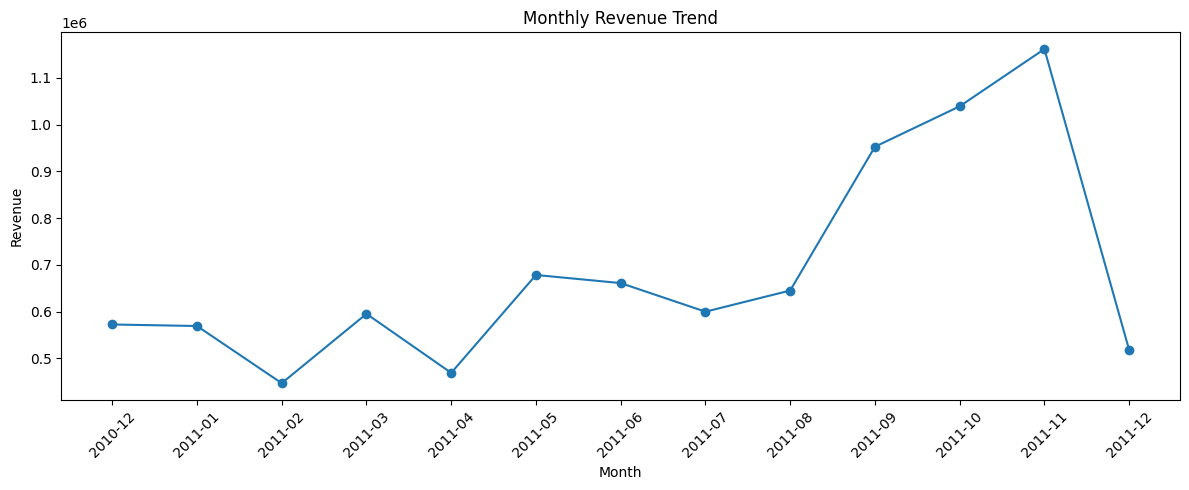

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Revenue"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()